In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import time

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

In [2]:
path="spam/spambase_csv.csv"
df=pd.read_csv(path,encoding="latin-1")
X=df.iloc[:,:-1]
y=df.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

Accuracy : 8.338762214983714e-01
Precision: 0.7178423236514523
Recall   : 0.953168044077135
F1 Score : 0.8189349112426035
ROC AUC  : 0.9449529508180535

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.76      0.85       558
           1       0.72      0.95      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.87      0.83      0.84       921



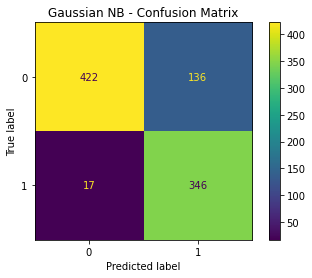

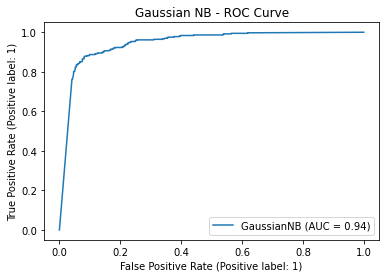

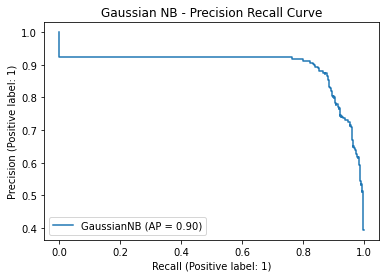

In [3]:
#Gaussian Naive Bayes
gnb=GaussianNB()
gnb.fit(X_train,y_train)
y_pred_g=gnb.predict(X_test)
y_prob_g=gnb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_g))
print("Precision:", precision_score(y_test, y_pred_g))
print("Recall   :", recall_score(y_test, y_pred_g))
print("F1 Score :", f1_score(y_test, y_pred_g))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_g))

print("\nClassification Report")
print(classification_report(y_test, y_pred_g))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_g)
plt.title("Gaussian NB - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(gnb, X_test, y_test)
plt.title("Gaussian NB - ROC Curve")
plt.show()

PrecisionRecallDisplay.from_estimator(gnb, X_test, y_test)
plt.title("Gaussian NB - Precision Recall Curve")
plt.show()

Accuracy : 7.763300760043431e-01
Precision: 0.7198879551820728
Recall   : 0.7079889807162535
F1 Score : 0.7138888888888889
ROC AUC  : 0.8248121488590697

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.82      0.82       558
           1       0.72      0.71      0.71       363

    accuracy                           0.78       921
   macro avg       0.77      0.76      0.77       921
weighted avg       0.78      0.78      0.78       921



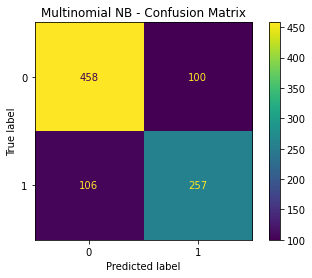

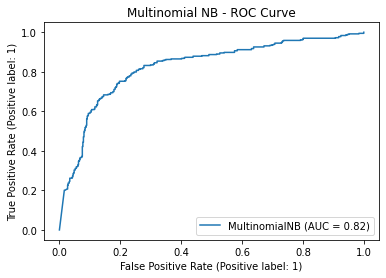

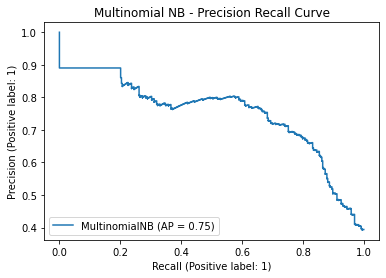

In [4]:
#Multinomial Naive Bayes

mnb=MultinomialNB()
mnb.fit(X_train, y_train)

y_pred_m = mnb.predict(X_test)
y_prob_m = mnb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_m))
print("Precision:", precision_score(y_test, y_pred_m))
print("Recall   :", recall_score(y_test, y_pred_m))
print("F1 Score :", f1_score(y_test, y_pred_m))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_m))

print("\nClassification Report")
print(classification_report(y_test, y_pred_m))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_m)
plt.title("Multinomial NB - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(mnb, X_test, y_test)
plt.title("Multinomial NB - ROC Curve")
plt.show()

PrecisionRecallDisplay.from_estimator(mnb, X_test, y_test)
plt.title("Multinomial NB - Precision Recall Curve")
plt.show()

Accuracy : 9.001085776330076e-01
Precision: 0.8594164456233422
Recall   : 0.8925619834710744
F1 Score : 0.8756756756756756
ROC AUC  : 0.9510056577505258

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       558
           1       0.86      0.89      0.88       363

    accuracy                           0.90       921
   macro avg       0.89      0.90      0.90       921
weighted avg       0.90      0.90      0.90       921



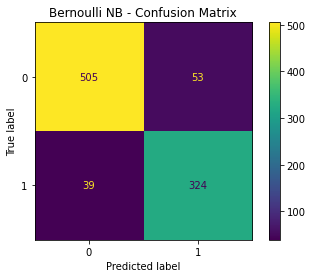

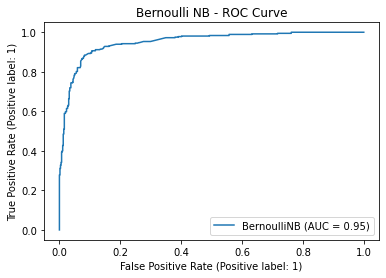

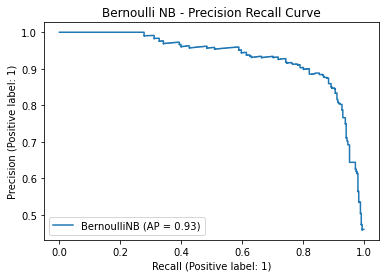

In [5]:
#Bernoulli Naive Bayes
X_binary=(X>0.5).astype(int)
X_train_b, X_test_b, y_train_b, y_test_b= train_test_split(X_binary,y,test_size=0.20,random_state=42,stratify=y)

bnb=BernoulliNB()
bnb.fit(X_train_b, y_train_b)

y_pred_b=bnb.predict(X_test_b)
y_prob_b=bnb.predict_proba(X_test_b)[:, 1]

print("Accuracy :", accuracy_score(y_test_b, y_pred_b))
print("Precision:", precision_score(y_test_b, y_pred_b))
print("Recall   :", recall_score(y_test_b, y_pred_b))
print("F1 Score :", f1_score(y_test_b, y_pred_b))
print("ROC AUC  :", roc_auc_score(y_test_b, y_prob_b))

print("\nClassification Report")
print(classification_report(y_test_b, y_pred_b))

ConfusionMatrixDisplay.from_predictions(y_test_b, y_pred_b)
plt.title("Bernoulli NB - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(bnb, X_test_b, y_test_b)
plt.title("Bernoulli NB - ROC Curve")
plt.show()

PrecisionRecallDisplay.from_estimator(bnb, X_test_b, y_test_b)
plt.title("Bernoulli NB - Precision Recall Curve")
plt.show()

K = 1
Accuracy : 8.023887079261672e-01
Precision: 0.7452574525745257
Recall   : 0.7575757575757576
F1 Score : 0.7513661202185793

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       558
           1       0.75      0.76      0.75       363

    accuracy                           0.80       921
   macro avg       0.79      0.79      0.79       921
weighted avg       0.80      0.80      0.80       921



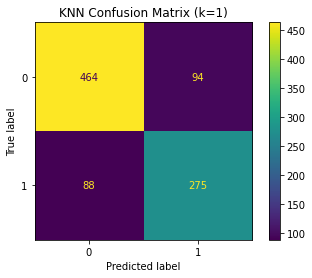

K = 3
Accuracy : 0.7893593919652552
Precision: 0.7393767705382436
Recall   : 0.71900826446281
F1 Score : 0.729050279329609

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       558
           1       0.74      0.72      0.73       363

    accuracy                           0.79       921
   macro avg       0.78      0.78      0.78       921
weighted avg       0.79      0.79      0.79       921



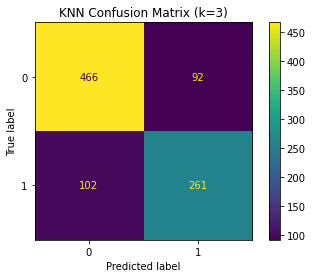

K = 5
Accuracy : 0.7991313789359392
Precision: 0.751412429378531
Recall   : 0.7327823691460055
F1 Score : 0.7419804741980474

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       558
           1       0.75      0.73      0.74       363

    accuracy                           0.80       921
   macro avg       0.79      0.79      0.79       921
weighted avg       0.80      0.80      0.80       921



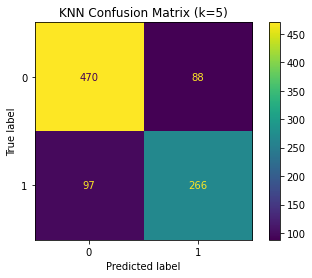

K = 7
Accuracy : 0.7926167209554832
Precision: 0.7457142857142857
Recall   : 0.71900826446281
F1 Score : 0.7321178120617111

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       558
           1       0.75      0.72      0.73       363

    accuracy                           0.79       921
   macro avg       0.78      0.78      0.78       921
weighted avg       0.79      0.79      0.79       921



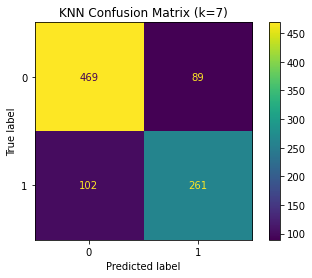

K = 9
Accuracy : 0.7893593919652552
Precision: 0.7407407407407407
Recall   : 0.7162534435261708
F1 Score : 0.7282913165266106

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       558
           1       0.74      0.72      0.73       363

    accuracy                           0.79       921
   macro avg       0.78      0.78      0.78       921
weighted avg       0.79      0.79      0.79       921



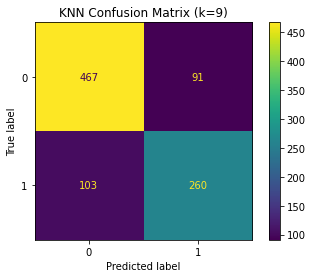

K = 11
Accuracy : 0.7795874049945711
Precision: 0.7285714285714285
Recall   : 0.7024793388429752
F1 Score : 0.7152875175315568

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       558
           1       0.73      0.70      0.72       363

    accuracy                           0.78       921
   macro avg       0.77      0.77      0.77       921
weighted avg       0.78      0.78      0.78       921



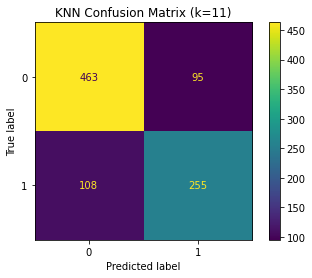

In [6]:
#KNN
k_values=[1,3,5,7,9,11]
accuracy=[]
precision=[]
recall=[]
f1=[]

for k in k_values:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred=knn.predict(X_test)

    accuracy.append(accuracy_score(y_test, y_pred))
    precision.append(precision_score(y_test, y_pred))
    recall.append(recall_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred))
    print(f"K = {k}")
    print("Accuracy :", accuracy[-1])
    print("Precision:", precision[-1])
    print("Recall   :", recall[-1])
    print("F1 Score :", f1[-1])

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"KNN Confusion Matrix (k={k})")
    plt.show()

In [9]:
#GridSearchCV
param_grid={'n_neighbors': [1,3,5,7,9,11],'weights': ['uniform','distance'],'metric': ['euclidean','manhattan'],
            'algorithm': ['auto','kd_tree','ball_tree']}

grid=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid_start=time.time()
grid.fit(X_train, y_train)
grid_end=time.time()

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Execution Time:", grid_end-grid_start)

Best Parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best CV Accuracy: 0.8595108695652174
Execution Time: 13.927167177200317


In [10]:
#RandomizedSearchCV
param_dist={'n_neighbors': range(1,21),'weights': ['uniform','distance'],'metric': ['euclidean','manhattan'],
            'algorithm': ['auto','kd_tree','ball_tree']}

random=RandomizedSearchCV(KNeighborsClassifier(),param_distributions=param_dist,n_iter=20,cv=5,scoring='accuracy',random_state=42,n_jobs=-1)
random_start=time.time()
random.fit(X_train,y_train)
random_end=time.time()

print("Best Parameters:", random.best_params_)
print("Best CV Accuracy:", random.best_score_)
print("Execution Time:", random_end-random_start)

Best Parameters: {'weights': 'distance', 'n_neighbors': 17, 'metric': 'manhattan', 'algorithm': 'ball_tree'}
Best CV Accuracy: 0.85625
Execution Time: 3.032214403152466


In [11]:
#KD Tree vs Ball Tree
algorithms=["kd_tree","ball_tree"]
kd_ball=[]
for algo in algorithms:
    knn=KNeighborsClassifier(n_neighbors=5,algorithm=algo)
    start_train=time.time()
    knn.fit(X_train,y_train)
    end_train=time.time()
    start_pred=time.time()
    y_pred=knn.predict(X_test)
    end_pred=time.time()
    kd_ball.append({"Algorithm":algo,"Accuracy":accuracy_score(y_test,y_pred),"Training Time":end_train-start_train,
                    "Prediction Time":end_pred-start_pred})

kd_ball_results=pd.DataFrame(kd_ball)
print(kd_ball_results)

   Algorithm  Accuracy  Training Time  Prediction Time
0    kd_tree  0.799131       0.024717         0.046634
1  ball_tree  0.799131       0.011576         0.071337


In [12]:
#Five Fold Corss Validation
best_knn=grid.best_estimator_
nb=GaussianNB()
nb_scores=cross_val_score(nb,X,y,cv=5,scoring='accuracy')
knn_scores=cross_val_score(best_knn,X,y,cv=5,scoring='accuracy')

cv_table=pd.DataFrame({"Fold":[1,2,3,4,5],"Naive Bayes":nb_scores,"Best KNN":knn_scores})
average_row=pd.DataFrame({"Fold":["Average"],"Naive Bayes":[nb_scores.mean()],"Best KNN":[knn_scores.mean()]})

cv_table=pd.concat([cv_table,average_row],ignore_index=True)
print(cv_table)

      Fold  Naive Bayes  Best KNN
0        1     0.850163  0.800217
1        2     0.870652  0.831522
2        3     0.855435  0.855435
3        4     0.852174  0.853261
4        5     0.700000  0.752174
5  Average     0.825685  0.818522


In [13]:
#Training VS Prediction Time
models={
    "Gaussian NB":GaussianNB(),
    "Multinomial NB":MultinomialNB(),
    "Bernoulli NB":BernoulliNB(),
    "Best KNN":grid.best_estimator_
}

time_results=[]
for name,model in models.items():
    start_train=time.time()
    model.fit(X_train,y_train)
    end_train=time.time()
    start_pred=time.time()
    model.predict(X_test)
    end_pred=time.time()
    time_results.append({"Algorithm":name,"Training Time":end_train-start_train,"Prediction Time":end_pred-start_pred})

time_df=pd.DataFrame(time_results)
print(time_df)

        Algorithm  Training Time  Prediction Time
0     Gaussian NB       0.005505         0.002675
1  Multinomial NB       0.004151         0.002010
2    Bernoulli NB       0.005730         0.002551
3        Best KNN       0.002339         0.311562


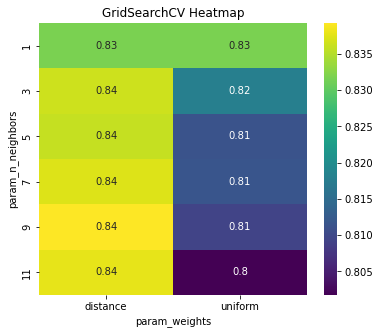

In [14]:
#GridSearchCV Heatmap
results=pd.DataFrame(grid.cv_results_)
heatmap=results.pivot_table(values='mean_test_score',index='param_n_neighbors',columns='param_weights')

plt.figure(figsize=(6,5))
sns.heatmap(heatmap,annot=True,cmap="viridis")

plt.title("GridSearchCV Heatmap")
plt.show()

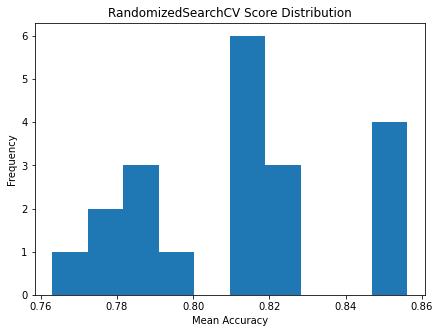

In [15]:
#RandomizedSearchCV Score Distribution
results_random=pd.DataFrame(random.cv_results_)
plt.figure(figsize=(7,5))
plt.hist(results_random["mean_test_score"],bins=10)
plt.xlabel("Mean Accuracy")
plt.ylabel("Frequency")
plt.title("RandomizedSearchCV Score Distribution")
plt.show()

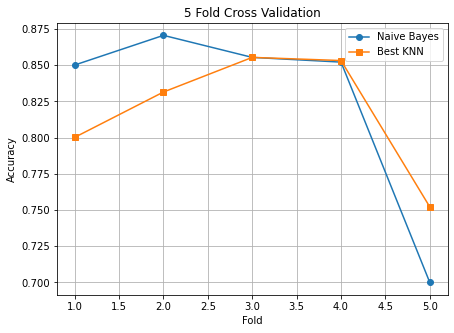

In [16]:
#Cross Validation Accuracy plot
plt.figure(figsize=(7,5))
plt.plot([1,2,3,4,5],nb_scores,marker='o',label="Naive Bayes")
plt.plot([1,2,3,4,5],knn_scores,marker='s',label="Best KNN")

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5 Fold Cross Validation")
plt.legend()
plt.grid()
plt.show()

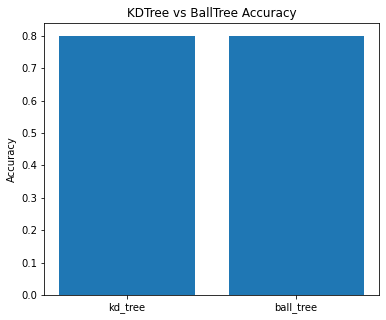

In [17]:
#KDTree VS BallTree
plt.figure(figsize=(6,5))
plt.bar(kd_ball_results["Algorithm"],kd_ball_results["Accuracy"])
plt.ylabel("Accuracy")
plt.title("KDTree vs BallTree Accuracy")
plt.show()